In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
from scipy import stats

In [2]:
ENTREPRISES = pd.DataFrame(
    [
        # Énergie 
        ("TotalEnergies",     "TTEF.PA",  "TTE.PA",   12, "Énergie",     "Énergie"),
        ("Technip Energies",  "TE.PA",    "TE.PA",    12, "Énergie",     "Énergie"),
        ("Vallourec",         "VLLP.PA",  "VK.PA",    12, "Énergie",     "Énergie"),
        ("GTT",               "GTT.PA",   "GTT.PA",   12, "Énergie",     "Énergie"),
        ("Maurel & Prom",     "MAUP.PA",  "MAU.PA",   12, "Énergie",     "Énergie"),
        ("Viridien",          "VIRI.PA",  "VIRI.PA",  12, "Énergie",     "Énergie"),
        ("Rubis",             "RUBF.PA",  "RUI.PA",   12, "Énergie",     "Énergie"),
        
        # Matériaux de base 
        ("Air Liquide",       "AIRP.PA",  "AI.PA",    12, "Matériaux",   "Chimie"),
        ("ArcelorMittal",     "MT.AS",    "MT.AS",    12, "Matériaux",   "Ressources de base"),
        ("Aperam",            "APAM.AS",  "APAM.AS",  12, "Matériaux",   "Ressources de base"),
        ("Eramet",            "ERMT.PA",  "ERA.PA",   12, "Matériaux",   "Ressources de base"),
        ("Imerys",            "IMTP.PA",  "NK.PA",    12, "Matériaux",   "Ressources de base"),
        ("Arkema",            "AKE.PA",   "AKE.PA",   12, "Matériaux",   "Chimie"),
        ("Solvay",            "SOLB.BR",  "SOLB.BR",  12, "Matériaux",   "Chimie"),
        
        # Construction & matériaux 
        ("Saint-Gobain",      "SGOB.PA",  "SGO.PA",   12, "Construction","Construction & matériaux"),
        ("Vinci",             "SGEF.PA",  "DG.PA",    12, "Construction","Construction & matériaux"),
        ("Eiffage",           "FOUG.PA",  "FGR.PA",   12, "Construction","Construction & matériaux"),
        ("Vicat",             "VCTP.PA",  "VCT.PA",   12, "Construction","Construction & matériaux"),
        
        # Biens industriels & services 
        ("Airbus",            "AIR.PA",   "AIR.PA",   12, "Industrie",   "Aéronautique & défense"),
        ("Safran",            "SAF.PA",   "SAF.PA",   12, "Industrie",   "Aéronautique & défense"),
        ("Thales",            "TCFP.PA",  "HO.PA",    12, "Industrie",   "Aéronautique & défense"),
        ("Dassault Aviation", "AM.PA",    "AM.PA",    12, "Industrie",   "Aéronautique & défense"),
        ("Schneider Electric","SCHN.PA",  "SU.PA",    12, "Industrie",   "Biens d'équipement"),
        ("Legrand",           "LEGD.PA",  "LR.PA",    12, "Industrie",   "Biens d'équipement"),
        ("Alstom",            "ALSO.PA",  "ALO.PA",    3, "Industrie",   "Biens d'équipement"),
        ("Nexans",            "NEXS.PA",  "NEX.PA",   12, "Industrie",   "Biens d'équipement"),
        ("Spie",              "SPIE.PA",  "SPIE.PA",  12, "Industrie",   "Services industriels"),
        ("Rexel",             "RXL.PA",   "RXL.PA",   12, "Industrie",   "Distribution industrielle"),
        ("Bureau Veritas",    "BVI.PA",   "BVI.PA",   12, "Industrie",   "Services industriels"),
        ("Elis",              "ELIS.PA",  "ELIS.PA",  12, "Industrie",   "Services industriels"),
        ("Derichebourg",      "DBG.PA",   "DBG.PA",    9, "Industrie",   "Services industriels"),
        ("ID Logistics",      "IDLA.PA",  "IDL.PA",   12, "Industrie",   "Transport & logistique"),
        ("Getlink",           "GETP.PA",  "GET.PA",   12, "Industrie",   "Transport & logistique"),
        ("Groupe ADP",        "ADP.PA",   "ADP.PA",   12, "Industrie",   "Transport & logistique"),
        ("Air France-KLM",    "AIRF.PA",  "AF.PA",    12, "Industrie",   "Transport & logistique"),
        ("Bouygues",          "BOUY.PA",  "EN.PA",    12, "Industrie",   "Conglomérat"),
        ("BIC",               "BICP.PA",  "BB.PA",    12, "Industrie",   "Biens durables"),
        ("Trigano",           "TRIA.PA",  "TRI.PA",    8, "Industrie",   "Biens durables"),
        ("Vusion",            "VU.PA",    "VU.PA",    12, "Industrie",   "Électronique"),
        ("LISI",              "GFII.PA",  "FII.PA",   12, "Industrie",   "Composants"),
        ("Mersen",            "CBLP.PA",  "MRN.PA",   12, "Industrie",   "Composants"),
        ("Exail Technologies","EXA.PA",   "EXA.PA",   12, "Industrie",   "Électronique & défense"),
        ("Exosens",           "EXENS.PA", "EXENS.PA", 12, "Industrie",   "Électronique & défense"),
        ("Teleperformance",   "TEPRF.PA", "TEP.PA",   12, "Industrie",   "Services aux entreprises"),
        ("Edenred",           "EDEN.PA",  "EDEN.PA",  12, "Industrie",   "Services aux entreprises"),
        ("Pluxee",            "PLX.PA",   "PLX.PA",    8, "Industrie",   "Services aux entreprises"),
        
        # Automobiles & équipementiers 
        ("Stellantis",        "STLAM.PA", "STLAP.PA", 12, "Automobile",  "Automobiles & équipementiers"),
        ("Renault",           "RENA.PA",  "RNO.PA",   12, "Automobile",  "Automobiles & équipementiers"),
        ("Michelin",          "MICP.PA",  "ML.PA",    12, "Automobile",  "Automobiles & équipementiers"),
        ("Forvia",            "FRVIA.PA", "FRVIA.PA", 12, "Automobile",  "Automobiles & équipementiers"),
        ("Valeo",             "VLOF.PA",  "FR.PA",    12, "Automobile",  "Automobiles & équipementiers"),
        ("OPmobility",        "OPM.PA",   "OPM.PA",   12, "Automobile",  "Automobiles & équipementiers"),
        
        # Conso. discrétionnaire : Luxe & biens personnels 
        ("LVMH",              "LVMH.PA",  "MC.PA",    12, "Conso. discr.","Luxe & biens personnels"),
        ("Hermès",            "HRMS.PA",  "RMS.PA",   12, "Conso. discr.","Luxe & biens personnels"),
        ("Kering",            "PRTP.PA",  "KER.PA",   12, "Conso. discr.","Luxe & biens personnels"),
        ("EssilorLuxottica",  "ESLX.PA",  "EL.PA",    12, "Conso. discr.","Luxe & biens personnels"),
        ("Interparfums",      "IPAR.PA",  "ITP.PA",   12, "Conso. discr.","Luxe & biens personnels"),
        ("SEB",               "SEBF.PA",  "SK.PA",    12, "Conso. discr.","Luxe & biens personnels"),
        
        # Conso. discrétionnaire : Voyage, loisirs & hôtellerie 
        ("Accor",             "ACCP.PA",  "AC.PA",    12, "Conso. discr.","Voyage & loisirs"),
        ("Sodexo",            "EXHO.PA",  "SW.PA",     8, "Conso. discr.","Voyage & loisirs"),
        ("FDJ",               "FDJU.PA",  "FDJU.PA",   12, "Conso. discr.","Voyage & loisirs"),
        ("Ubisoft",           "UBIP.PA",  "UBI.PA",    3, "Conso. discr.","Voyage & loisirs"),
        
        # Conso. discrétionnaire : Médias 
        ("Publicis",          "PUBP.PA",  "PUB.PA",   12, "Conso. discr.","Médias"),
        ("JCDecaux",          "JCDX.PA",  "DEC.PA",   12, "Conso. discr.","Médias"),
        ("TF1",               "TFFP.PA",  "TFI.PA",   12, "Conso. discr.","Médias"),
        ("M6",                "MMTP.PA",  "MMT.PA",   12, "Conso. discr.","Médias"),
        ("Ipsos",             "ISOS.PA",  "IPS.PA",   12, "Conso. discr.","Médias"),
        ("Vivendi",           "VIV.PA",   "VIV.PA",   12, "Conso. discr.","Médias"),
        
        # Conso. de base : Alimentation, boissons & distribution 
        ("Danone",            "DANO.PA",  "BN.PA",    12, "Conso. base", "Alimentation & boissons"),
        ("Pernod Ricard",     "PERP.PA",  "RI.PA",     6, "Conso. base", "Alimentation & boissons"),
        ("Rémy Cointreau",    "RCOP.PA",  "RCO.PA",    3, "Conso. base", "Alimentation & boissons"),
        ("Carrefour",         "CARR.PA",  "CA.PA",    12, "Conso. base", "Distribution alimentaire"),
        ("Verallia",          "VRLA.PA",  "VRLA.PA",  12, "Conso. base", "Emballage"),
        
        # Conso. de base : Soins personnels & droguerie
        ("L'Oréal",           "OREP.PA",  "OR.PA",    12, "Conso. base", "Soins personnels"),
        # Santé 
        ("Sanofi",            "SASY.PA",  "SAN.PA",   12, "Santé",       "Pharmacie"),
        ("BioMérieux",        "BIOX.PA",  "BIM.PA",   12, "Santé",       "Équipements & services médicaux"),
        ("Sartorius Stedim",  "STDM.PA",  "DIM.PA",   12, "Santé",       "Équipements & services médicaux"),
        ("Ipsen",             "IPN.PA",   "IPN.PA",   12, "Santé",       "Pharmacie"),
        ("Eurofins Scientific","EUFI.PA", "ERF.PA",   12, "Santé",       "Équipements & services médicaux"),
        ("Virbac",            "VIRB.PA",  "VIRP.PA",  12, "Santé",       "Pharmacie"),
        ("Abivax",            "ABVX.PA",  "ABVX.PA",  12, "Santé",       "Biotechnologie"),
        ("DBV Technologies",  "DBV.PA",   "DBV.PA",   12, "Santé",       "Biotechnologie"),
        ("MedinCell",         "MEDCL.PA", "MEDCL.PA",  3, "Santé",       "Biotechnologie"),
        ("Nanobiotix",        "NANOB.PA", "NANO.PA",  12, "Santé",       "Biotechnologie"),
        ("Valneva",           "VLS.PA",   "VLA.PA",   12, "Santé",       "Biotechnologie"),
        ("Clariane",          "CLARI.PA", "CLARI.PA", 12, "Santé",       "Services de santé"),
        ("Emeis",             "EMEIS.PA", "EMEIS.PA", 12, "Santé",       "Services de santé"),
        
        # Finance : Banques & assurance 
        ("BNP Paribas",       "BNPP.PA",  "BNP.PA",   12, "Finance",     "Banques"),
        ("Crédit Agricole",   "CAGR.PA",  "ACA.PA",   12, "Finance",     "Banques"),
        ("Société Générale",  "SOGN.PA",  "GLE.PA",   12, "Finance",     "Banques"),
        ("AXA",               "AXAF.PA",  "CS.PA",    12, "Finance",     "Assurance"),
        ("SCOR",              "SCOR.PA",  "SCR.PA",   12, "Finance",     "Assurance"),
        ("Coface",            "COFA.PA",  "COFA.PA",  12, "Finance",     "Assurance"),
        
        # Finance : Gestion & divers 
        ("Amundi",            "AMUN.PA",  "AMUN.PA",  12, "Finance",     "Services financiers"),
        ("Euronext",          "ENX.PA",   "ENX.PA",   12, "Finance",     "Services financiers"),
        ("Eurazeo",           "EURA.PA",  "RF.PA",    12, "Finance",     "Holdings & capital-inv."),
        ("Wendel",            "MWDP.PA",  "MF.PA",    12, "Finance",     "Holdings & capital-inv."),
        ("Bolloré",           "BOLL.PA",  "BOL.PA",   12, "Finance",     "Holdings & capital-inv."),
        ("Ayvens",            "AYV.PA",   "AYV.PA",   12, "Finance",     "Services financiers"),
        
        # Immobilier (foncières) 
        ("Argan",             "ARGAN.PA", "ARG.PA",   12, "Immobilier",  "Foncières"),
        ("Unibail-Rodamco-W.","URW.PA",   "URW.PA",   12, "Immobilier",  "Foncières"),
        ("Gecina",            "GFCP.PA",  "GFC.PA",   12, "Immobilier",  "Foncières"),
        ("Klépierre",         "LOIM.PA",  "LI.PA",    12, "Immobilier",  "Foncières"),
        ("Covivio",           "CVO.PA",   "COV.PA",   12, "Immobilier",  "Foncières"),
        ("Icade",             "ICAD.PA",  "ICAD.PA",  12, "Immobilier",  "Foncières"),
        ("Mercialys",         "MERY.PA",  "MERY.PA",  12, "Immobilier",  "Foncières"),
        ("Carmila",           "CARM.PA",  "CARM.PA",  12, "Immobilier",  "Foncières"),
        
        # Technologie 
        ("Dassault Systèmes", "DAST.PA",  "DSY.PA",   12, "Technologie", "Logiciels & services"),
        ("Capgemini",         "CAPP.PA",  "CAP.PA",   12, "Technologie", "Logiciels & services"),
        ("STMicroelectronics","STMPA.PA", "STMPA.PA", 12, "Technologie", "Semi-conducteurs"),
        ("Worldline",         "WLN.PA",   "WLN.PA",   12, "Technologie", "Paiements & fintech"),
        ("Sopra Steria",      "SOPR.PA",  "SOP.PA",   12, "Technologie", "Logiciels & services"),
        ("Alten",             "LTEN.PA",  "ATE.PA",   12, "Technologie", "Logiciels & services"),
        ("Atos",              "ATOS.PA",  "ATO.PA",   12, "Technologie", "Logiciels & services"),
        ("Soitec",            "SOIT.PA",  "SOI.PA",    3, "Technologie", "Semi-conducteurs"),
        
        # Télécommunications
        ("Orange",            "ORAN.PA",  "ORA.PA",   12, "Télécoms",    "Télécommunications"),
        ("Eutelsat",          "ETL.PA",   "ETL.PA",    6, "Télécoms",    "Télécommunications"),
        ("SES",               "SESFd.PA", "SESG.PA",  12, "Télécoms",    "Télécommunications"),
        
        # Services aux collectivités (Utilities) 
        ("Engie",             "ENGIE.PA", "ENGI.PA",  12, "Utilities",   "Services aux collectivités"),
        ("Veolia",            "VIE.PA",   "VIE.PA",   12, "Utilities",   "Services aux collectivités"),
    ],
    columns=["nom", "ric", "yahoo", "mois_cloture", "secteur", "sous_secteur"],)


ENTREPRISES

,nom,ric,yahoo,mois_cloture,secteur,sous_secteur
0,TotalEnergies,TTEF.PA,TTE.PA,12,Énergie,Énergie
1,Technip Energies,TE.PA,TE.PA,12,Énergie,Énergie
2,Vallourec,VLLP.PA,VK.PA,12,Énergie,Énergie
3,GTT,GTT.PA,GTT.PA,12,Énergie,Énergie
4,Maurel & Prom,MAUP.PA,MAU.PA,12,Énergie,Énergie
...,...,...,...,...,...,...
115,Orange,ORAN.PA,ORA.PA,12,Télécoms,Télécommunications
116,Eutelsat,ETL.PA,ETL.PA,6,Télécoms,Télécommunications
117,SES,SESFd.PA,SESG.PA,12,Télécoms,Télécommunications
118,Engie,ENGIE.PA,ENGI.PA,12,Utilities,Services aux collectivités


In [3]:
rics = ENTREPRISES["ric"].tolist()

noms = dict(zip(rics, ENTREPRISES["nom"]))

cloture = dict(zip(rics, ENTREPRISES["mois_cloture"]))

secteurs = dict(zip(ENTREPRISES["nom"], ENTREPRISES["secteur"])) 

tickers = dict(zip(ENTREPRISES["nom"], ENTREPRISES["yahoo"]))



##### PARAMETRES A DEFINIR POUR CADRER L'ETUDE ######

ANNEE_DEP = 2013
EST_WIN     = (-200, -20)        # la fenêtre d'estimation en jours de bourse 
MIN_OBS     = 120                # le nombre minimum d'observation 
H_MAX       = 40                 # dernier jour de la fenêtre d'événement pour mesurer le CAR
REACT_END   = 1                  # durée de la réaction immédiate (on utilise [t0, t0+1])
DRIFT_START = 2                  # jour de bourse à partir du quel on mesure le CAR après réaction immédiate

In [4]:
### on importe la moyenne des BPA prédits par les analystes pour chaque annonce ###
mean = pd.read_csv("EpsMean.csv",
                   sep = ";", 
                   decimal = ",", 
                   encoding = "utf-8-sig" 
)


# on supprime les colonnes inutiles
df_mean = mean[["Financial Period Absolute"] + rics]


df_mean = df_mean.melt(
    id_vars = "Financial Period Absolute", 
    var_name = "Entreprise", 
    value_name = "EPS Mean")


# on nettoie pour garder que les annonces sur la période
df_mean = df_mean.dropna()

df_mean = df_mean.rename(columns = {"Financial Period Absolute":"Financial Period"})

df_mean["Financial Period"] = df_mean["Financial Period"].str.replace("FY","").astype(int)

df_mean = df_mean.loc[df_mean["Financial Period"] >= ANNEE_DEP]

df_mean

,Financial Period,Entreprise,EPS Mean
7,2013,TTEF.PA,6.54230
8,2014,TTEF.PA,5.34908
9,2015,TTEF.PA,4.14606
10,2016,TTEF.PA,3.41573
11,2017,TTEF.PA,4.15613
...,...,...,...
2395,2021,VIE.PA,1.31570
2396,2022,VIE.PA,1.49554
2397,2023,VIE.PA,1.80627
2398,2024,VIE.PA,2.04500


In [5]:
actual = pd.read_csv("EpsAct.csv",
                     sep = ";", 
                     decimal = ",",
                     encoding = "utf-8-sig")

df_act = actual[["Date"] + rics]

df_act = df_act.melt(
    id_vars = "Date", 
    var_name = "Entreprise",
    value_name = "EPS Actual")

df_act = df_act.dropna()



# On met les dates dans le bon format
df_act["Financial Period"] = pd.to_datetime(df_act["Date"],
                                dayfirst = True).dt.year
df_act["mois_annonce"] = pd.to_datetime(df_act["Date"], 
                                        dayfirst = True).dt.month

df_act["mois_cloture"] = df_act["Entreprise"].map(cloture)

for i in df_act.index:
    if df_act.loc[i,"mois_annonce"] < df_act.loc[i,"mois_cloture"]: 
        df_act.loc[i, "Financial Period"] = df_act.loc[i, "Financial Period"] - 1
        
df_act = df_act[df_act["Financial Period"] >= ANNEE_DEP]

df_act = df_act.drop(columns=["mois_annonce","mois_cloture"])

df_act

,Date,Entreprise,EPS Actual,Financial Period
1697,12/02/2014 06:58,TTEF.PA,6.28055,2013
1698,12/02/2015 07:00,TTEF.PA,5.63000,2014
1699,11/02/2016 08:30,TTEF.PA,4.51000,2015
1700,09/02/2017 07:24,TTEF.PA,3.38000,2016
1701,08/02/2018 08:56,TTEF.PA,4.12000,2017
...,...,...,...,...
232190,28/02/2020 06:45,VIE.PA,1.07987,2019
232191,25/02/2021 06:28,VIE.PA,0.19283,2020
232192,17/03/2022 06:30,VIE.PA,0.65000,2021
232193,29/02/2024 07:33,VIE.PA,1.28000,2023


In [6]:
df = df_act.merge(df_mean, 
                  on =["Entreprise","Financial Period"],
                  how = "inner")


# On nettoie tout ça

df["Entreprise"] = df["Entreprise"].map(noms)

df = df[["Date",
         "Entreprise",
         "Financial Period",
         "EPS Mean",
         "EPS Actual"]]


# On calcule l'écart de BPA et on classe la surprise selon son signe
df["Ecart_BPA"] = df["EPS Actual"] - df["EPS Mean"]

df["Surprise"] = np.where(df["Ecart_BPA"] >= 0, 
                          "Positif", 
                          "Négatif")

df

,Date,Entreprise,Financial Period,EPS Mean,EPS Actual,Ecart_BPA,Surprise
0,12/02/2014 06:58,TotalEnergies,2013,6.54230,6.28055,-0.26175,Négatif
1,12/02/2015 07:00,TotalEnergies,2014,5.34908,5.63000,0.28092,Positif
2,11/02/2016 08:30,TotalEnergies,2015,4.14606,4.51000,0.36394,Positif
3,09/02/2017 07:24,TotalEnergies,2016,3.41573,3.38000,-0.03573,Négatif
4,08/02/2018 08:56,TotalEnergies,2017,4.15613,4.12000,-0.03613,Négatif
...,...,...,...,...,...,...,...
1468,28/02/2020 06:45,Veolia,2019,1.23709,1.07987,-0.15722,Négatif
1469,25/02/2021 06:28,Veolia,2020,0.72444,0.19283,-0.53161,Négatif
1470,17/03/2022 06:30,Veolia,2021,1.31570,0.65000,-0.66570,Négatif
1471,29/02/2024 07:33,Veolia,2023,1.80627,1.28000,-0.52627,Négatif


In [7]:
df["Date_dt"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Secteur"] = df["Entreprise"].map(secteurs)




n_pos = int((df["Surprise"] == "Positif").sum())
n_neg = int((df["Surprise"] == "Négatif").sum())



print(f"Échantillon : {len(df)} annonces | {n_pos} positives ({n_pos/len(df):.0%}) "
      f"| {n_neg} négatives ({n_neg/len(df):.0%})")
print(f"Période : {df['Date_dt'].min():%d/%m/%Y} à {df['Date_dt'].max():%d/%m/%Y}")
print(f"Entreprises : {df['Entreprise'].nunique()}")

df = df.drop(columns=["Date_dt"])

print("\nRépartition par secteur :")
print(df.groupby(["Secteur", "Surprise"]).size().unstack(fill_value=0).to_string())

Échantillon : 1473 annonces | 795 positives (54%) | 678 négatives (46%)
Période : 07/05/2013 à 08/04/2026
Entreprises : 120

Répartition par secteur :
Surprise       Négatif  Positif
Secteur                        
Automobile          45       25
Conso. base         30       42
Conso. discr.       86      116
Construction        15       37
Finance             56       92
Immobilier          47       46
Industrie          165      172
Matériaux           48       43
Santé               78       80
Technologie         35       68
Télécoms            24       15
Utilities            8       18
Énergie             41       41


In [8]:
tickers_liste = ENTREPRISES["yahoo"].tolist()

donnees = yf.download(tickers_liste, start="2012-01-01", end="2026-07-01", auto_adjust=False)

## prix = le prix ajusté des dividendes et splits (pour calculer les rendements)
prix = donnees["Adj Close"]


# prix_brut = prix ajusté que des splits (pour mesurer niveau de surprise)
prix_brut = donnees["Close"]

# on visualise brièvement le nombre de jours pour lesquels on a pas de prix par société
print(prix.shape)
print(prix.isna().sum())

[*********************100%***********************]  120 of 120 completed

(3708, 120)
Ticker
ABVX.PA     889
AC.PA         2
ACA.PA        2
ADP.PA        2
AF.PA         2
           ... 
VK.PA         2
VLA.PA        2
VRLA.PA    1983
VU.PA         2
WLN.PA      635
Length: 120, dtype: int64


In [9]:
# on retire les jours où aucun titre n'est coté

na_par_jour = prix.isna().sum(axis=1)
garder = na_par_jour < prix.shape[1]
prix = prix[garder]
prix_brut = prix_brut[garder]
print("Lignes restantes :", len(prix))

# on comble (seulement) les petits espaces où des prix manquent
# on prend arbitrairement une limite de 3j manquants d'affilé
prix = prix.ffill(limit=3)
prix_brut = prix_brut.ffill(limit=3)

Lignes restantes : 3708


In [10]:
# SBF 120 rendement global (dividendes réinvestis), cohérent avec Adj Close
sbf = pd.read_csv("Sbf_gross_return",
                  encoding="utf-8-sig")

sbf["Date"] = pd.to_datetime(sbf["Date"], format="%d/%m/%Y")

sbf = sbf.set_index("Date")

# la colonne du cours s'appelle "Price" (anglais) ou "Dernier" (français)
col = "Price" if "Price" in sbf.columns else "Dernier"
sbf = sbf[[col]].rename(columns = {col:"SBF"})

# conversion en nombre, que le fichier écrive "13,456.78" ou "13.456,78"
def en_nombre(x):
    x = str(x).replace(" ", "").replace("\u202f", "")
    if "," in x and "." in x:
        if x.rfind(",") > x.rfind("."):          # format français
            x = x.replace(".", "").replace(",", ".")
        else:                                    # format anglais
            x = x.replace(",", "")
    else:
        x = x.replace(",", ".")
    return float(x)

sbf["SBF"] = sbf["SBF"].apply(en_nombre)

sbf = sbf[~sbf.index.duplicated(keep="first")].sort_index()

print(f"Indice du {sbf.index.min():%d/%m/%Y} au {sbf.index.max():%d/%m/%Y}, {len(sbf)} jours")
print(sbf.head(3))

prix = prix.join(sbf, how = "inner")

prix.head()

Indice du 02/01/2012 au 25/09/2026, 3769 jours
                SBF
Date               
2012-01-02  4547.95
2012-01-03  4581.98
2012-01-04  4513.51


,ABVX.PA,AC.PA,ACA.PA,ADP.PA,AF.PA,AI.PA,AIR.PA,AKE.PA,ALO.PA,AM.PA,...,VIE.PA,VIRI.PA,VIRP.PA,VIV.PA,VK.PA,VLA.PA,VRLA.PA,VU.PA,WLN.PA,SBF
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-02,NaN,14.645144,2.056011,39.098221,20.879995,34.816460,19.569727,33.885727,17.663849,47.084530,...,4.448267,13516.180664,111.644272,1.725654,345.984283,5.64,NaN,8.970757,NaN,4547.95
2012-01-03,NaN,14.733277,2.056011,39.098221,20.784168,34.938332,19.569727,34.804981,17.916763,48.334560,...,4.398980,13964.430664,111.895676,1.715305,349.549103,5.68,NaN,8.961830,NaN,4581.98
2012-01-04,NaN,14.446836,1.994326,38.928555,20.229387,34.716080,19.621647,33.837669,17.671179,48.084553,...,4.225232,13696.926758,111.271805,1.674899,348.943726,5.70,NaN,8.961830,NaN,4513.51
2012-01-05,NaN,13.925369,1.890436,38.212978,19.215649,34.106720,19.881243,32.383701,17.040720,48.751236,...,4.087827,13902.976562,111.271805,1.644347,345.177185,5.60,NaN,9.060019,NaN,4443.84
2012-01-06,NaN,14.031867,1.915018,38.360512,19.957039,34.017113,19.781399,32.263542,16.688837,49.084583,...,4.046505,13935.511719,109.744743,1.631043,346.455139,5.63,NaN,9.060019,NaN,4435.43


In [11]:
# Rendements quotidiens à partir de la table prix
rend = prix.pct_change()
rend = rend.iloc[1:]
rend.head()

,ABVX.PA,AC.PA,ACA.PA,ADP.PA,AF.PA,AI.PA,AIR.PA,AKE.PA,ALO.PA,AM.PA,...,VIE.PA,VIRI.PA,VIRP.PA,VIV.PA,VK.PA,VLA.PA,VRLA.PA,VU.PA,WLN.PA,SBF
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,NaN,0.006018,0.000000,0.000000,-0.004589,0.003500,0.000000,0.027128,0.014318,0.026549,...,-0.011080,0.033164,0.002252,-0.005997,0.010303,0.007092,NaN,-0.000995,NaN,0.007482
2012-01-04,NaN,-0.019442,-0.030002,-0.004339,-0.026692,-0.006361,0.002653,-0.027792,-0.013707,-0.005172,...,-0.039497,-0.019156,-0.005575,-0.023557,-0.001732,0.003521,NaN,0.000000,NaN,-0.014943
2012-01-05,NaN,-0.036096,-0.052093,-0.018382,-0.050112,-0.017553,0.013230,-0.042969,-0.035677,0.013865,...,-0.032520,0.015044,0.000000,-0.018241,-0.010794,-0.017544,NaN,0.010956,NaN,-0.015436
2012-01-06,NaN,0.007648,0.013003,0.003861,0.038583,-0.002627,-0.005022,-0.003710,-0.020650,0.006838,...,-0.010108,0.002340,-0.013724,-0.008091,0.003702,0.005357,NaN,0.000000,NaN,-0.001893
2012-01-09,NaN,-0.016226,-0.020829,-0.003846,-0.036391,-0.001265,0.004038,0.009870,-0.004612,0.016129,...,-0.017717,-0.004929,-0.034872,-0.013897,-0.011260,0.012433,NaN,0.000000,NaN,-0.003220


In [12]:
# Datation de l'événement 

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Heure"] = df["Date"].dt.time

df["Date"]  = df["Date"].dt.normalize()

# Règle : 
# si une annonce >= 17:30 (clôture Paris) => le jour de référence = lendemain
cloture = pd.Timestamp("17:30").time()
df["Jour_ref"] = df["Date"]
df.loc[df["Heure"] >= cloture, "Jour_ref"] = df["Date"] + pd.Timedelta(days=1)

# t0 = premier jour de bourse >= Jour_ref
jours = rend.index
positions = jours.searchsorted(df["Jour_ref"], side="left")
df["t0"] = jours[positions]

df = df.drop(columns = "Jour_ref")

df[["Entreprise", "Date", "t0"]].head()

,Entreprise,Date,t0
0,TotalEnergies,2014-02-12,2014-02-12
1,TotalEnergies,2015-02-12,2015-02-12
2,TotalEnergies,2016-02-11,2016-02-11
3,TotalEnergies,2017-02-09,2017-02-09
4,TotalEnergies,2018-02-08,2018-02-08


Annonces sans prix la veille de t0 : 10
Annonces exclues (échelle BPA / prix) : 39
Bornes de winsorisation : -19.283% et 9.795%


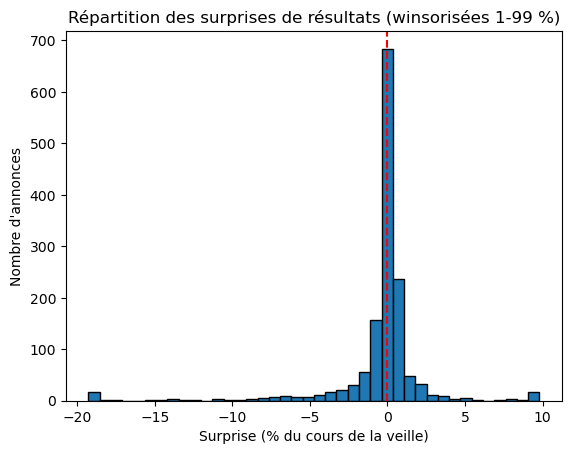

In [13]:
# Surprise normalisée par le prix
# On divise l'écart de BPA par le cours de clôture de la veille de t0
# pour que le dénominateur ne contienne pas la réaction à l'annonce

jours = rend.index
pos_t0 = jours.get_indexer(df["t0"])
df["Date_prix"] = jours[pos_t0 - 1]

df["Prix_veille"] = [prix_brut.at[d, tickers[e]]
                     for d, e in zip(df["Date_prix"], df["Entreprise"])]

sans_prix = df["Prix_veille"].isna() | (df["Prix_veille"] <= 0)
print(f"Annonces sans prix la veille de t0 : {sans_prix.sum()}")
df = df[~sans_prix].copy()

# Entreprises exclues : échelle du BPA incohérente avec celle du cours
# (regroupements d'actions ajustés différemment par LSEG et Yahoo)
EXCLUS = ["Atos", "Emeis", "Viridien"]
exclu = df["Entreprise"].isin(EXCLUS)
print(f"Annonces exclues (échelle BPA / prix) : {exclu.sum()}")
df = df[~exclu].copy()

df["Surprise_prix"] = df["Ecart_BPA"] / df["Prix_veille"]

# Winsorisation aux 1er et 99e centiles
bas, haut = df["Surprise_prix"].quantile([0.01, 0.99])
df["Surprise_w"] = df["Surprise_prix"].clip(bas, haut)
print(f"Bornes de winsorisation : {bas:.3%} et {haut:.3%}")

df = df.drop(columns="Date_prix")

# Distribution de la surprise winsorisée
plt.hist(df["Surprise_w"] * 100, bins=40, edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Surprise (% du cours de la veille)")
plt.ylabel("Nombre d'annonces")
plt.title("Répartition des surprises de résultats (winsorisées 1-99 %)")
plt.show()

In [14]:
#
#
#

In [15]:
#

In [16]:
alphas = []
betas = []
n_obs = []
ecarte = []

for idx, event in df.iterrows(): 
    
    ticker = tickers[event["Entreprise"]]
    t0 = event["t0"]
    pos = rend.index.get_loc(t0)

    deb = pos + EST_WIN[0]
    fin = pos + EST_WIN[1]

    if deb < 0:
        alphas.append(np.nan)
        betas.append(np.nan)
        n_obs.append(0)
        ecarte.append((event["Entreprise"], t0, "fenetre_hors_calendrier"))
        continue

    fenetre = rend.iloc[deb:fin]
    x = fenetre["SBF"]
    y = fenetre[ticker]

    ok = x.notna() & y.notna()
    x, y = x[ok], y[ok]

    if len(x) < MIN_OBS:
        alphas.append(np.nan)
        betas.append(np.nan)
        n_obs.append(len(x))
        ecarte.append((event["Entreprise"], t0, f"obs={len(x)}"))
        continue

    beta, alpha = np.polyfit(x,y,1)
    alphas.append(alpha)
    betas.append(beta)
    n_obs.append(len(x))

# On ajoute les résultats dans le tableau
df["alpha"] = alphas
df["beta"]  = betas
df["n_obs_est"] = n_obs

# Garde-fou économique : un beta plausible est dans une fourchette raisonnable
BETA_MIN, BETA_MAX = -1.0, 3.0

# On exclut les events au beta implausible (estimation non fiable) 
beta_aberrant = df["beta"].notna() & ((df["beta"] < BETA_MIN) | (df["beta"] > BETA_MAX))
df.loc[beta_aberrant, ["alpha", "beta"]] = np.nan

print(f"\nEvents avec beta valide : {df['beta'].notna().sum()} / {len(df)}")
print(df["beta"].describe().round(3).to_string())


Events avec beta valide : 1420 / 1424
count    1420.000
mean        0.909
std         0.379
min        -0.263
25%         0.648
50%         0.889
75%         1.136
max         2.367


In [17]:
car_immediat = []      # réaction [t0, t0+1]
car_20 = []            # dérive [t0+2, t0+20]
car_40 = []            # dérive [t0+2, t0+40]
n_jours_drift = []     # garde-fou : nb de jours valides dans la dérive
trajectoires = {}      # {index_event: Series du CAR cumulé jour par jour}

for idx, event in df.iterrows():
    beta = event["beta"]
    if pd.isna(beta):                      # events au market model invalidé -> pas de CAR
        car_immediat.append(np.nan); car_20.append(np.nan)
        car_40.append(np.nan); n_jours_drift.append(0)
        continue

    ticker = tickers[event["Entreprise"]]
    alpha  = event["alpha"]
    pos = rend.index.get_loc(event["t0"])

    # Garde-fou : assez de jours après t0 pour couvrir +40 ?
    if pos + H_MAX >= len(rend):
        car_immediat.append(np.nan); car_20.append(np.nan)
        car_40.append(np.nan); n_jours_drift.append(0)
        continue

    # Rendement anormal quotidien sur toute la fenêtre [t0, t0+40]
    fen = rend.iloc[pos : pos + H_MAX + 1]          # t0 à t0+40 inclus
    ar = fen[ticker] - (alpha + beta * fen["SBF"])   # AR jour par jour

    # ar.iloc[0] = AR à t0, ar.iloc[1] = AR à t0+1, ..., ar.iloc[40] = AR à t0+40

    # Réaction immédiate : [t0, t0+1] = crans 0 et 1
    car_imm = ar.iloc[REACT_END-1 : REACT_END+1].sum()   # somme AR t0 et t0+1

    # Dérive : [t0+2, t0+40] = crans DRIFT_START à H_MAX
    drift = ar.iloc[DRIFT_START : H_MAX + 1]
    car_immediat.append(car_imm)
    car_20.append(drift.iloc[: 20 - DRIFT_START + 1].sum())   # jusqu'à t0+20
    car_40.append(drift.sum())                                # jusqu'à t0+40
    n_jours_drift.append(drift.notna().sum())

    # Trajectoire : CAR cumulé jour par jour sur la dérive
    trajectoires[idx] = drift.cumsum().reset_index(drop=True)

# On rattache au df
df["AR_immediat"] = car_immediat
df["CAR_20"] = car_20
df["CAR_40"] = car_40
df["n_jours_drift"] = n_jours_drift

# --- Affichage sélectif demandé ---
cols= ["Entreprise", "t0", "Surprise", "Surprise_w",
             "AR_immediat", "CAR_20", "CAR_40"]
print(f"Events avec CAR : {df['CAR_40'].notna().sum()} / {len(df)}")
df[cols].head(5)

Events avec CAR : 1420 / 1424


,Entreprise,t0,Surprise,Surprise_w,AR_immediat,CAR_20,CAR_40
0,TotalEnergies,2014-02-12,Négatif,-0.006006,0.003005,0.039347,0.067894
1,TotalEnergies,2015-02-12,Positif,0.005983,-0.011425,-0.089656,-0.058467
2,TotalEnergies,2016-02-11,Positif,0.009965,0.060819,-0.006798,0.004482
3,TotalEnergies,2017-02-09,Négatif,-0.000763,0.010255,-0.058592,-0.044523
4,TotalEnergies,2018-02-08,Négatif,-0.000807,0.024572,0.010653,0.063059


In [18]:
from scipy import stats

def moyenne_et_test(serie):
    """Moyenne du groupe + p-value du test de Student (H0 : moyenne = 0)."""
    x = serie.dropna()
    if len(x) < 2:
        return np.nan, np.nan
    moy = x.mean()
    _, p = stats.ttest_1samp(x, 0.0)
    return moy, p

def afficher_p(p):
    """p-value formatée avec étoiles de significativité."""
    if pd.isna(p):
        return ""
    etoiles = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    return f"{p:.3f}{etoiles}"



# Classification principale : 5 groupes de surprise (quintiles)
# Q1 = surprises les plus négatives, Q5 = surprises les plus positives

NOMS_Q = ["Négative forte", "Négative faible", "Neutre",
          "Positive faible", "Positive forte"]

data_q = df.dropna(subset=["AR_immediat", "CAR_20", "CAR_40"]).copy()
data_q["Quintile"] = pd.qcut(data_q["Surprise_w"], 5, labels=NOMS_Q)

lignes = []
for q in NOMS_Q:
    groupe = data_q[data_q["Quintile"] == q]
    ligne = {"Groupe": q,
             "N": len(groupe),
             "Surprise médiane": groupe["Surprise_w"].median()}
    for col, nom in [("AR_immediat", "immédiat"), ("CAR_20", "20j"), ("CAR_40", "40j")]:
        moy, p = moyenne_et_test(groupe[col])
        ligne[f"CAR {nom} moyen"] = moy
        ligne[f"p CAR {nom}"] = afficher_p(p)
    lignes.append(ligne)

tableau_q = pd.DataFrame(lignes)

# Mise en forme lisible (surprise et CAR en %)
fmt_q = tableau_q.copy()
for c in ["Surprise médiane", "CAR immédiat moyen", "CAR 20j moyen", "CAR 40j moyen"]:
    fmt_q[c] = (fmt_q[c] * 100).round(3)

fmt_q

,Groupe,N,Surprise médiane,CAR immédiat moyen,p CAR immédiat,CAR 20j moyen,p CAR 20j,CAR 40j moyen,p CAR 40j
0,Négative forte,284,-2.159,-0.837,0.071*,1.630,0.075*,2.697,0.035**
1,Négative faible,284,-0.251,0.527,0.119,-0.270,0.520,0.472,0.442
2,Neutre,284,0.038,0.263,0.348,-1.016,0.041**,-0.222,0.758
3,Positive faible,284,0.261,1.919,0.000***,-0.769,0.043**,-1.614,0.006***
4,Positive forte,284,1.057,1.716,0.000***,0.714,0.236,0.546,0.507


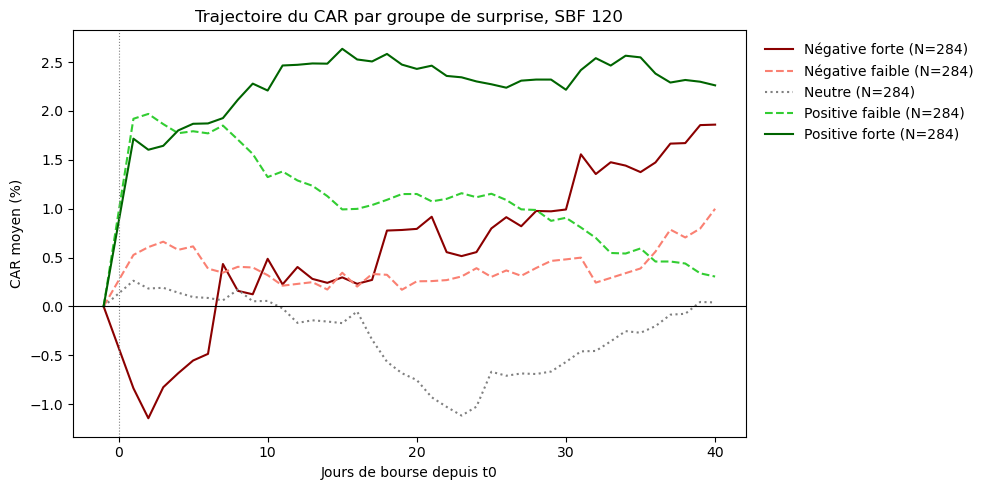

In [19]:
# Trajectoires moyennes du CAR par groupe de surprise, de la veille de t0 à t0+40
# Le CAR part de 0 à la veille de t0, intègre la réaction [t0, t0+1],
# puis cumule la dérive jusqu'à t0+40

traj = pd.DataFrame(trajectoires)   # lignes = jours t0+2 à t0+40, colonnes = événements

styles_q = {
    "Négative forte":  ("darkred",   "-"),
    "Négative faible": ("salmon",    "--"),
    "Neutre":          ("grey",      ":"),
    "Positive faible": ("limegreen", "--"),
    "Positive forte":  ("darkgreen", "-"),
}

plt.figure(figsize=(10, 5))

for q, (couleur, style) in styles_q.items():
    ids = [i for i in data_q.index[data_q["Quintile"] == q] if i in traj.columns]

    imm = df.loc[ids, "AR_immediat"]
    chemin = traj[ids].add(imm, axis=1)      # CAR depuis t0 = réaction + dérive
    moy = chemin.mean(axis=1) * 100

    x = [-1, 1] + list(range(DRIFT_START, DRIFT_START + len(moy)))
    y = [0, imm.mean() * 100] + list(moy)
    plt.plot(x, y, label=f"{q} (N={len(ids)})", color=couleur, linestyle=style)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="grey", linestyle=":", linewidth=0.8)   # jour de l'annonce
plt.xlabel("Jours de bourse depuis t0")
plt.ylabel("CAR moyen (%)")
plt.title("Trajectoire du CAR par groupe de surprise, SBF 120")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
plt.tight_layout()
plt.show()

In [20]:
# Statistiques descriptives des groupes de surprise
# Petite capitalisation = tiers inférieur de l'échantillon

cap = pd.read_csv("MarketCap.csv", decimal=",", sep=";")
cap = cap.drop(columns=["Updated at 21:16:43", "Currency"], errors="ignore")
cap["Date"] = pd.to_datetime(cap["Date"], dayfirst=True)
cap = (cap.rename(columns=noms)
          .melt(id_vars="Date", var_name="Entreprise", value_name="Cap")
          .dropna().sort_values("Date"))

data_q = data_q.drop(columns=["Cap", "Petite_cap"], errors="ignore")
tmp = pd.merge_asof(data_q.reset_index().sort_values("Date"), cap,
                    on="Date", by="Entreprise", direction="backward").set_index("index")
data_q["Cap"] = tmp["Cap"]
data_q["Petite_cap"] = data_q["Cap"] <= data_q["Cap"].quantile(1/3)

desc = data_q.groupby("Quintile", observed=True).agg(
    N=("Entreprise", "size"),
    Entreprises=("Entreprise", "nunique"),
    Cap_mediane=("Cap", "median"),
    Petites_cap=("Petite_cap", "mean")).loc[NOMS_Q]

desc["Cap_mediane"] = (desc["Cap_mediane"] / 1e9).round(1)
desc["Petites_cap"] = (desc["Petites_cap"] * 100).round(1)
desc.columns = ["N", "Entreprises", "Cap. médiane (Md€)", "Petites cap. (%)"]

desc

,N,Entreprises,Cap. médiane (Md€),Petites cap. (%)
Quintile,,,,
Négative forte,284,74,2.6,58.5
Négative faible,284,94,6.0,29.9
Neutre,284,88,10.7,15.8
Positive faible,284,95,9.2,20.1
Positive forte,284,87,4.4,41.2


In [21]:
# Robustesse : CAR moyens sans les 5 annonces les plus extrêmes de chaque groupe
# (extrêmes en valeur absolue, retirés séparément pour chaque horizon)

N_RETIRE = 5

lignes = []
for q in NOMS_Q:
    groupe = data_q[data_q["Quintile"] == q]
    ligne = {"Groupe": q, "N": len(groupe) - N_RETIRE}
    for col, nom in [("CAR_20", "20j"), ("CAR_40", "40j")]:
        x = groupe[col].dropna()
        x = x.drop(x.abs().nlargest(N_RETIRE).index)
        moy, p = moyenne_et_test(x)
        ligne[f"CAR {nom} moyen"] = moy
        ligne[f"p CAR {nom}"] = afficher_p(p)
    lignes.append(ligne)

fmt_sans5 = pd.DataFrame(lignes)
for c in ["CAR 20j moyen", "CAR 40j moyen"]:
    fmt_sans5[c] = (fmt_sans5[c] * 100).round(3)

fmt_sans5

,Groupe,N,CAR 20j moyen,p CAR 20j,CAR 40j moyen,p CAR 40j
0,Négative forte,279,0.566,0.371,0.924,0.335
1,Négative faible,279,-0.254,0.503,0.170,0.768
2,Neutre,279,-0.370,0.366,0.038,0.951
3,Positive faible,279,-0.683,0.050**,-1.327,0.013**
4,Positive forte,279,-0.034,0.947,-0.123,0.860


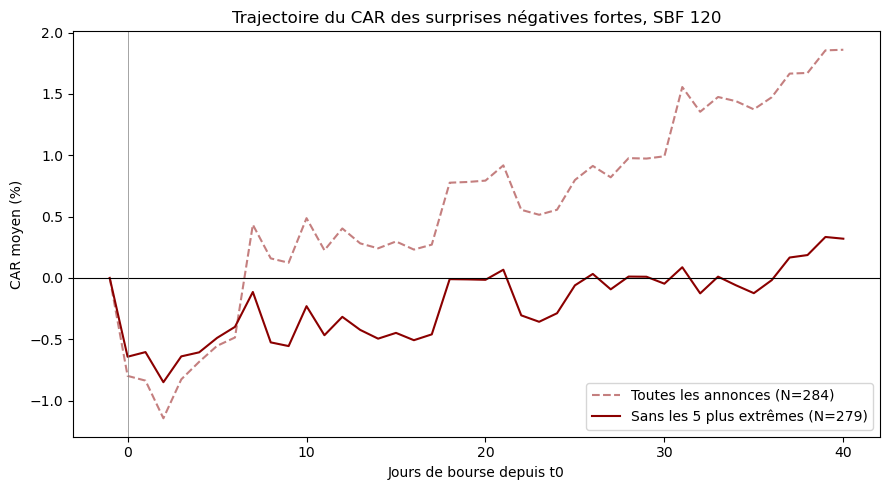

In [22]:
# Trajectoire des négatives fortes, avec et sans les 5 annonces les plus extrêmes

H = 40
N_RETIRE = 5

groupe = data_q[data_q["Quintile"] == "Négative forte"]
extremes = groupe["CAR_40"].abs().nlargest(N_RETIRE).index

# AR de t0 à t0+40 pour chaque annonce du groupe
ar_nf = {}
for idx, ev in groupe.iterrows():
    tk = tickers[ev["Entreprise"]]
    pos = rend.index.get_loc(ev["t0"])
    fen = rend.iloc[pos : pos + H + 1]
    ar_nf[idx] = (fen[tk] - (ev["alpha"] + ev["beta"] * fen["SBF"])).to_numpy()
ar_nf = pd.DataFrame(ar_nf, index=range(H + 1))

# CAR cumulé depuis la veille de t0 (CAR = 0 à t = -1)
def trajectoire(cols):
    car = ar_nf[cols].mean(axis=1).cumsum() * 100
    return pd.concat([pd.Series([0.0], index=[-1]), car])

tous = trajectoire(groupe.index)
sans = trajectoire(groupe.index.drop(extremes))

plt.figure(figsize=(9, 5))
plt.plot(tous.index, tous, color="darkred", linestyle="--", alpha=0.5,
         label=f"Toutes les annonces (N={len(groupe)})")
plt.plot(sans.index, sans, color="darkred",
         label=f"Sans les {N_RETIRE} plus extrêmes (N={len(groupe) - N_RETIRE})")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.5)
plt.xlabel("Jours de bourse depuis t0")
plt.ylabel("CAR moyen (%)")
plt.title("Trajectoire du CAR des surprises négatives fortes, SBF 120")
plt.legend()
plt.tight_layout()
plt.show()